In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We do the same calculations as in "btc_std_calc_fixed_tick.ipynb", but we use the price change adjustments that we got in "2_states_transitions_and_means.ipynb"

P $$= [[0.59758503,0.40241497], [0.44562421 0.55437579]]$$, denote as $P_{uu} = 0.597, P_{ud} = 0.402$

In [2]:
P = np.array([[0.59758503,0.40241497],[0.44562421 ,0.55437579]])

$$\pi = [0.52547614, 0.47452386]

In [3]:
pi = np.array([0.52547614, 0.47452386])

$$\implies \Pi^* = [[0.52547614, 0.47452386],[0.52547614, 0.47452386]]

In [4]:
Pi = np.array([pi,pi])

Took $$ a(1) = 5.204852406436644, a(-1) =-5.708821642654295 \implies a^* = 0.026053669880182095$$

$$\implies b(1) = 5.18, b(-1) = -5.72 \implies b^T = [5.18,-5.72]$$

In [5]:
b = np.array([5.18,-5.72])

$$ g:= (P + \Pi^* -I){^-1} b$$

In [6]:
A= np.linalg.inv(P + Pi - np.eye(2))

In [7]:
print(A)

[[-0.0340782  1.0340782]
 [ 1.1451126 -0.1451126]]


In [8]:
g = np.matmul(A,b)


In [9]:
print(g)

[-6.0914524   6.76172734]


$$\implies g = [-6.0914524   6.76172734]$$

$$v(1) = b(1)^2 + [ (g(-1)-g(1))^2 P(1,-1)] - 2b(1) [ (g(-1)-g(1)) P(1,-1)]

In [10]:
# v(1) = b(1)^2 + [ (g(-1)-g(1))^2 * P(1,-1)] - 2*b(1) * [ (g(-1)-g(1)) * P(1,-1)]
v1 = b[0]**2 + ((g[1]-g[0])**2) * P[0,1] - 2*b[0]*(g[1]-g[0])*P[0,1]
print('v(1) =', v1)
v2 = b[1]**2 + ((g[0]-g[1])**2) * P[1,0] - 2*b[1]*(g[0]-g[1])*P[1,0]
print('v(2) =', v2)

v(1) = 39.72790328474357
v(2) = 40.81265268096544


In [11]:
v = np.array([v1,v2])
print(v)

[39.72790328 40.81265268]


$$\sigma ^2 = \pi _1 v(1) + \pi _2 v(2)$$

In [12]:
sigma = np.sqrt(np.matmul(pi,v))

In [13]:
print(sigma)

6.343708911620349


But we see that we need $$\sigma \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.00031458686590702084, a =  0.02230285826488395, b =  0.04458713874443153$$

In [14]:
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [15]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [16]:
h_hat = a/b * mu

In [17]:
print(h_hat)

0.7473862003013596


In [18]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [19]:
print(par)

5.128311251164073


In [20]:
data_interval =  np.linspace(1, +1200, 100)

In [21]:
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]


Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


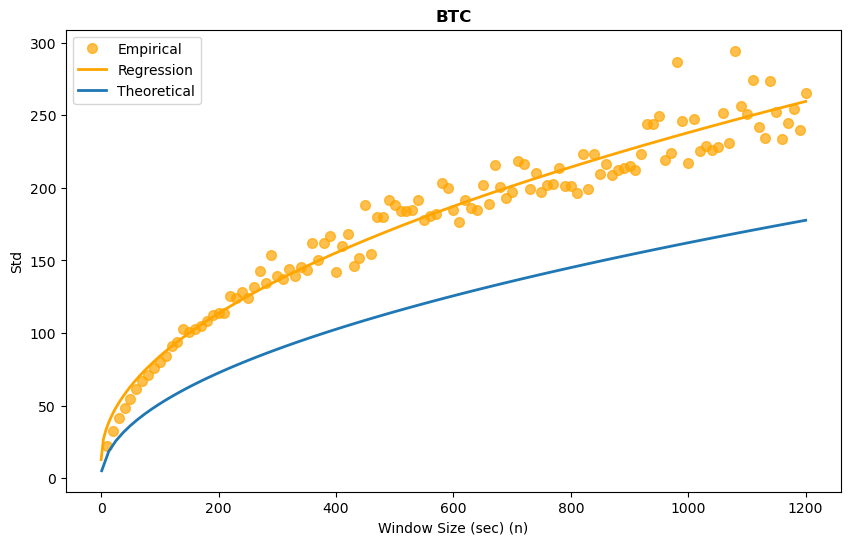

In [22]:

# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

MSE = $$\frac{1}{N} \sum_{i=1}^N (y_i -\hat{y}_i)^2$$

In [23]:
y_hat = np.sqrt(x)*par

In [24]:
MSE = np.array([(y[i]-y_hat[i])**2   for i in range(len(y_hat))])

In [25]:
MSE = np.sum(MSE) / len(MSE)

In [31]:
print(f"Mean square error: {MSE}")

Mean square error: 3912.8449169194705


In [32]:
print(f"Percentage error: %{((par-7.123004)/7.123004)*100}")

Percentage error: %-28.00353262241503
